In [15]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from lameg.surf import create_surf_gifti
from lameg.viz import show_surface, color_map
from lameg.util import get_bigbrain_layer_boundaries, load_meg_sensor_data, convert_native_to_fsaverage
from scipy.signal import correlate
import io
from PIL import Image
from base64 import b64decode

In [2]:
%env SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/
preproc_data_dir='/home/common/bonaiuto/cued_action_meg/derivatives/processed'

env: SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/


In [10]:
fsave_lh_coords, fsave_lh_faces = nib.freesurfer.io.read_geometry(os.path.join(preproc_data_dir, 'fs', 'fsaverage/surf/lh.pial_semi_inflated'))
fsave_lh = create_surf_gifti(fsave_lh_coords, fsave_lh_faces)

In [11]:
subjects=[
    'sub-001',
    'sub-002',
    'sub-003',
    'sub-004',
    'sub-005',
    'sub-006',
    'sub-007',
    'sub-008'
]
sessions={
    'sub-001': ['ses-01'],
    'sub-002': ['ses-03','ses-04','ses-05','ses-06'],
    'sub-003': ['ses-01','ses-02','ses-03','ses-04'],
    'sub-004': ['ses-01','ses-02','ses-03','ses-04'],
    'sub-005': ['ses-01','ses-02','ses-03','ses-04'],
    'sub-006': ['ses-03'],
    'sub-007': ['ses-01','ses-02','ses-03','ses-04'],
    'sub-008': ['ses-03','ses-04','ses-05']
}
polarity={
    'sub-001': [-1],
    'sub-002': [-1,-1,-1,-1],
    'sub-003': [-1,-1,-1,-1],
    'sub-004': [-1,-1,-1,-1],
    'sub-005': [-1,-1,1,-1],
    'sub-006': [-1],
    'sub-007': [1,-1,1,-1],
    'sub-008': [-1,-1,-1]
}
subj_session_idx = {}
subj_coords={
    subject: [] for subject in subjects
}
time_lims=[-500, 500]
n_layers=11
        
out_dir=os.path.join('/home/bonaiuto/laminar_erf/output/motor_epoch/02_mefI/patch_size_5.00mm')

all_prior_ts=[]
all_layer_F_diff=[]
all_snrs=[]

overall_ses_idx = 0
for subject in subjects:
    subj_session_idx[subject] = []
    
    for sess_idx, session in enumerate(sessions[subject]):
        session_polarity=polarity[subject][sess_idx]
        out_fname = os.path.join(out_dir,f'results_{subject}_{session}.npz')
        if os.path.exists(out_fname):
            data_dir=os.path.join(preproc_data_dir,subject,session,'spm')
            orig_data_file=f'spm_converted_{subject}-{session}-motor-epo.mat'
            sensor_data, sensor_time, ch_names = load_meg_sensor_data(os.path.join(data_dir, orig_data_file))
            sensor_time=sensor_time
            st_idx=np.where((sensor_time>=time_lims[0]) & (sensor_time<=time_lims[1]))[0]
            sensor_data=sensor_data[:,st_idx,:]
            sensor_time=sensor_time[st_idx]
            # Compute mean signal across trials (shape: n_channels x n_times)
            mean_signal = np.mean(sensor_data, axis=2)
            # Compute residual noise (trial-by-trial deviations from mean)
            noise = sensor_data - mean_signal[:, :, np.newaxis]
            # Compute RMS of signal and noise over channels
            rms_signal = np.sqrt(np.mean(mean_signal**2, axis=0))  # shape: (n_times,)
            rms_noise = np.sqrt(np.mean(np.mean(noise**2, axis=2), axis=0))  # shape: (n_times,)
            # Compute SNR time series in dB
            snr_db = 20 * np.log10(rms_signal / rms_noise)

            subj_surf_dir=os.path.join(preproc_data_dir,subject,'surf')
            ds_pial = nib.load(os.path.join(subj_surf_dir, 'pial.ds.gii'))

            data = np.load(out_fname, allow_pickle=True)
            prior = data['prior']
            prior_ts = data['prior_ts']*1000
            ts_time = data['ts_time']
            Fs = data['Fs']
            wois = data['wois']
            
            prior_coord=ds_pial.darrays[0].data[prior,:]
            hemi, fsave_idx = convert_native_to_fsaverage(subject, subj_surf_dir, subj_coord=prior_coord)
            fsave_coord = fsave_lh_coords[fsave_idx]

            woi_time=np.mean(wois,axis=-1)
            t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
            woi_win=woi_time[t_idx]
            Fs_win=Fs[:,t_idx]

            ts_idx=np.where((ts_time>=time_lims[0]) & (ts_time<=time_lims[1]))[0]
            prior_ts=prior_ts[ts_idx]
            ts_time=ts_time[ts_idx]

            surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(subject, subj_surf_dir, subj_coord=ds_pial.darrays[0].data[prior,:])
            
            prior_ts = session_polarity*prior_ts

            layers=np.arange(n_layers)
            layer1_idx=np.where((layers<surf_bb_bounds[0]))[0]
            layer2_idx=np.where((layers>=surf_bb_bounds[0]) & (layers<surf_bb_bounds[1]))[0]
            layer3_idx=np.where((layers>=surf_bb_bounds[1]) & (layers<surf_bb_bounds[2]))[0]
            layer4_idx=np.where((layers>=surf_bb_bounds[2]) & (layers<surf_bb_bounds[3]))[0]
            layer5_idx=np.where((layers>=surf_bb_bounds[3]) & (layers<surf_bb_bounds[4]))[0]
            layer6_idx=np.where((layers>=surf_bb_bounds[4]))[0]

            layer_F = np.vstack([
                np.mean(Fs_win[layer1_idx,:],axis=0),
                np.mean(Fs_win[layer2_idx,:],axis=0),
                np.mean(Fs_win[layer3_idx,:],axis=0),
                np.mean(Fs_win[layer4_idx,:],axis=0),
                np.mean(Fs_win[layer5_idx,:],axis=0),
                np.mean(Fs_win[layer6_idx,:],axis=0)
            ])
            layer_F_diff = np.zeros((layer_F.shape[0],layer_F.shape[1]))
            for t in range(layer_F.shape[1]):
                minF = np.nanmin(layer_F[:,t])
                layer_F_diff[:,t] = layer_F[:,t]-minF
            
            subj_session_idx[subject].append(overall_ses_idx)
            subj_coords[subject].append(fsave_coord)
            all_snrs.append(snr_db)
            all_prior_ts.append(prior_ts)
            all_layer_F_diff.append(layer_F_diff)
            overall_ses_idx = overall_ses_idx+1
            
all_snrs=np.array(all_snrs)
all_prior_ts=np.array(all_prior_ts)
all_layer_F_diff=np.array(all_layer_F_diff)

/home/bonaiuto/miniconda3/envs/lameg_test/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/bonaiuto/miniconda3/envs/lameg_test/lib/python3.7/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


In [16]:
cam_view = [-10, -42, 203,
            4, -21, 19.45,
            0, 1, 0]
subj_colors=[
    [228,26,28],
    [55,126,184],
    [77,175,74],
    [152,78,163],
    [255,127,0],
    [255,255,51],
    [166,86,40],
    [247,129,191]
]
coord_colors=[]
all_coords=[]
for s_idx, subject in enumerate(subjects):
    for coord in subj_coords[subject]:
        all_coords.append(coord)
        coord_colors.append(subj_colors[s_idx])
plot = show_surface(
    fsave_lh, 
    opacity=1, 
    coords=all_coords,
    coord_size=4,
    coord_color=coord_colors,
    camera_view=cam_view
)

Output()

In [17]:
plot.fetch_screenshot()

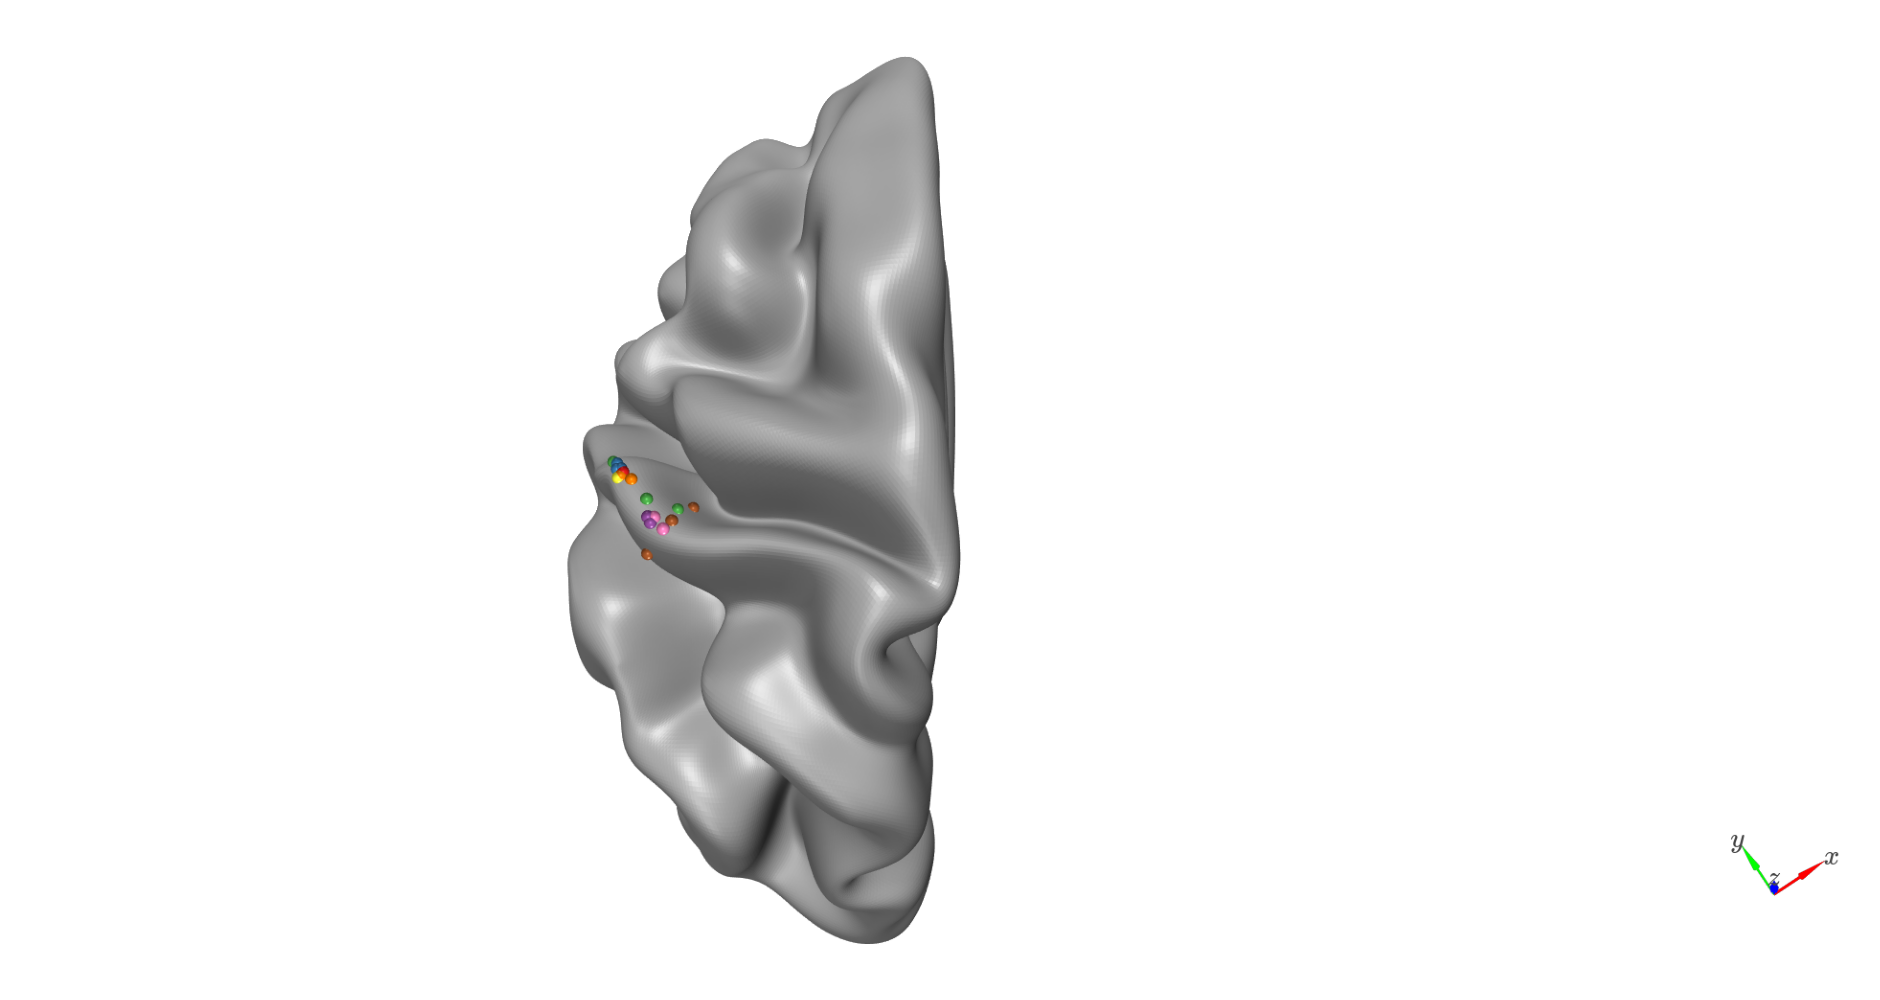

In [20]:
image_data = b64decode(plot.screenshot)

image = Image.open(io.BytesIO(image_data))

image_array = np.array(image)

plt.figure(figsize=(24,16))
plt.imshow(image_array)
plt.axis('off')  # To turn off the axis
plt.savefig('./figure_08_cued_action_mefI_localization.pdf')

In [4]:
def minmax_unit(x):
    x = np.asarray(x)
    xmin, xmax = np.min(x), np.max(x)
    if xmax == xmin:
        return np.zeros_like(x)
    return 2 * (x - xmin) / (xmax - xmin) - 1

def _best_lag(x, y, max_lag=None):
    n = len(x)
    if max_lag is None:
        max_lag = n // 4
    c = correlate(y, x, mode='full')
    lags = np.arange(-n + 1, n)
    sel = (lags >= -max_lag) & (lags <= max_lag)
    lag_win = lags[sel]
    return lag_win[np.argmax(c[sel])]

def woody_align_indices(X, ref_idx=0, max_lag=1000, n_iter=1000):
    """
    X: (n_series, n_time)
    ref_idx: index of the reference series (default: 0)
    Returns:
        lags:      (n_series,) integer sample lags relative to reference
        align_idx: list of index arrays for each series
        template:  final alignment template
    """
    X = np.asarray(X)
    n_series, n_time = X.shape
    template = minmax_unit(X[ref_idx])
    lags = np.zeros(n_series, dtype=int)

    for _ in range(max(n_iter, 1)):
        for i in range(n_series):
            xi = minmax_unit(X[i])
            lags[i] = _best_lag(xi, template, max_lag=max_lag)

        aligned_stack = []
        for i in range(n_series):
            idx = np.clip(np.arange(n_time) + lags[i], 0, n_time - 1)
            aligned_stack.append(X[i, idx])
        template = minmax_unit(np.nanmean(np.vstack(aligned_stack), axis=0))

    align_idx = [np.clip(np.arange(n_time) + l, 0, n_time - 1) for l in lags]
    return lags, align_idx, template

ref_idx = 0

lags, align_idx, woody_template = woody_align_indices(
    all_prior_ts, ref_idx=ref_idx, max_lag=50, n_iter=3
)

aligned_snrs = []
aligned_prior_ts = []
aligned_layer_F_diff = []

for ss_idx in range(all_prior_ts.shape[0]):
    aligned_idx = align_idx[ss_idx]

    aligned_snrs.append(all_snrs[ss_idx, aligned_idx])
    aligned_prior_ts.append(all_prior_ts[ss_idx, aligned_idx])
    aligned_layer_F_diff.append(all_layer_F_diff[ss_idx, :, aligned_idx])

aligned_snrs = np.array(aligned_snrs)
aligned_prior_ts = np.array(aligned_prior_ts)
aligned_layer_F_diff = np.transpose(np.array(aligned_layer_F_diff), (0, 2, 1))


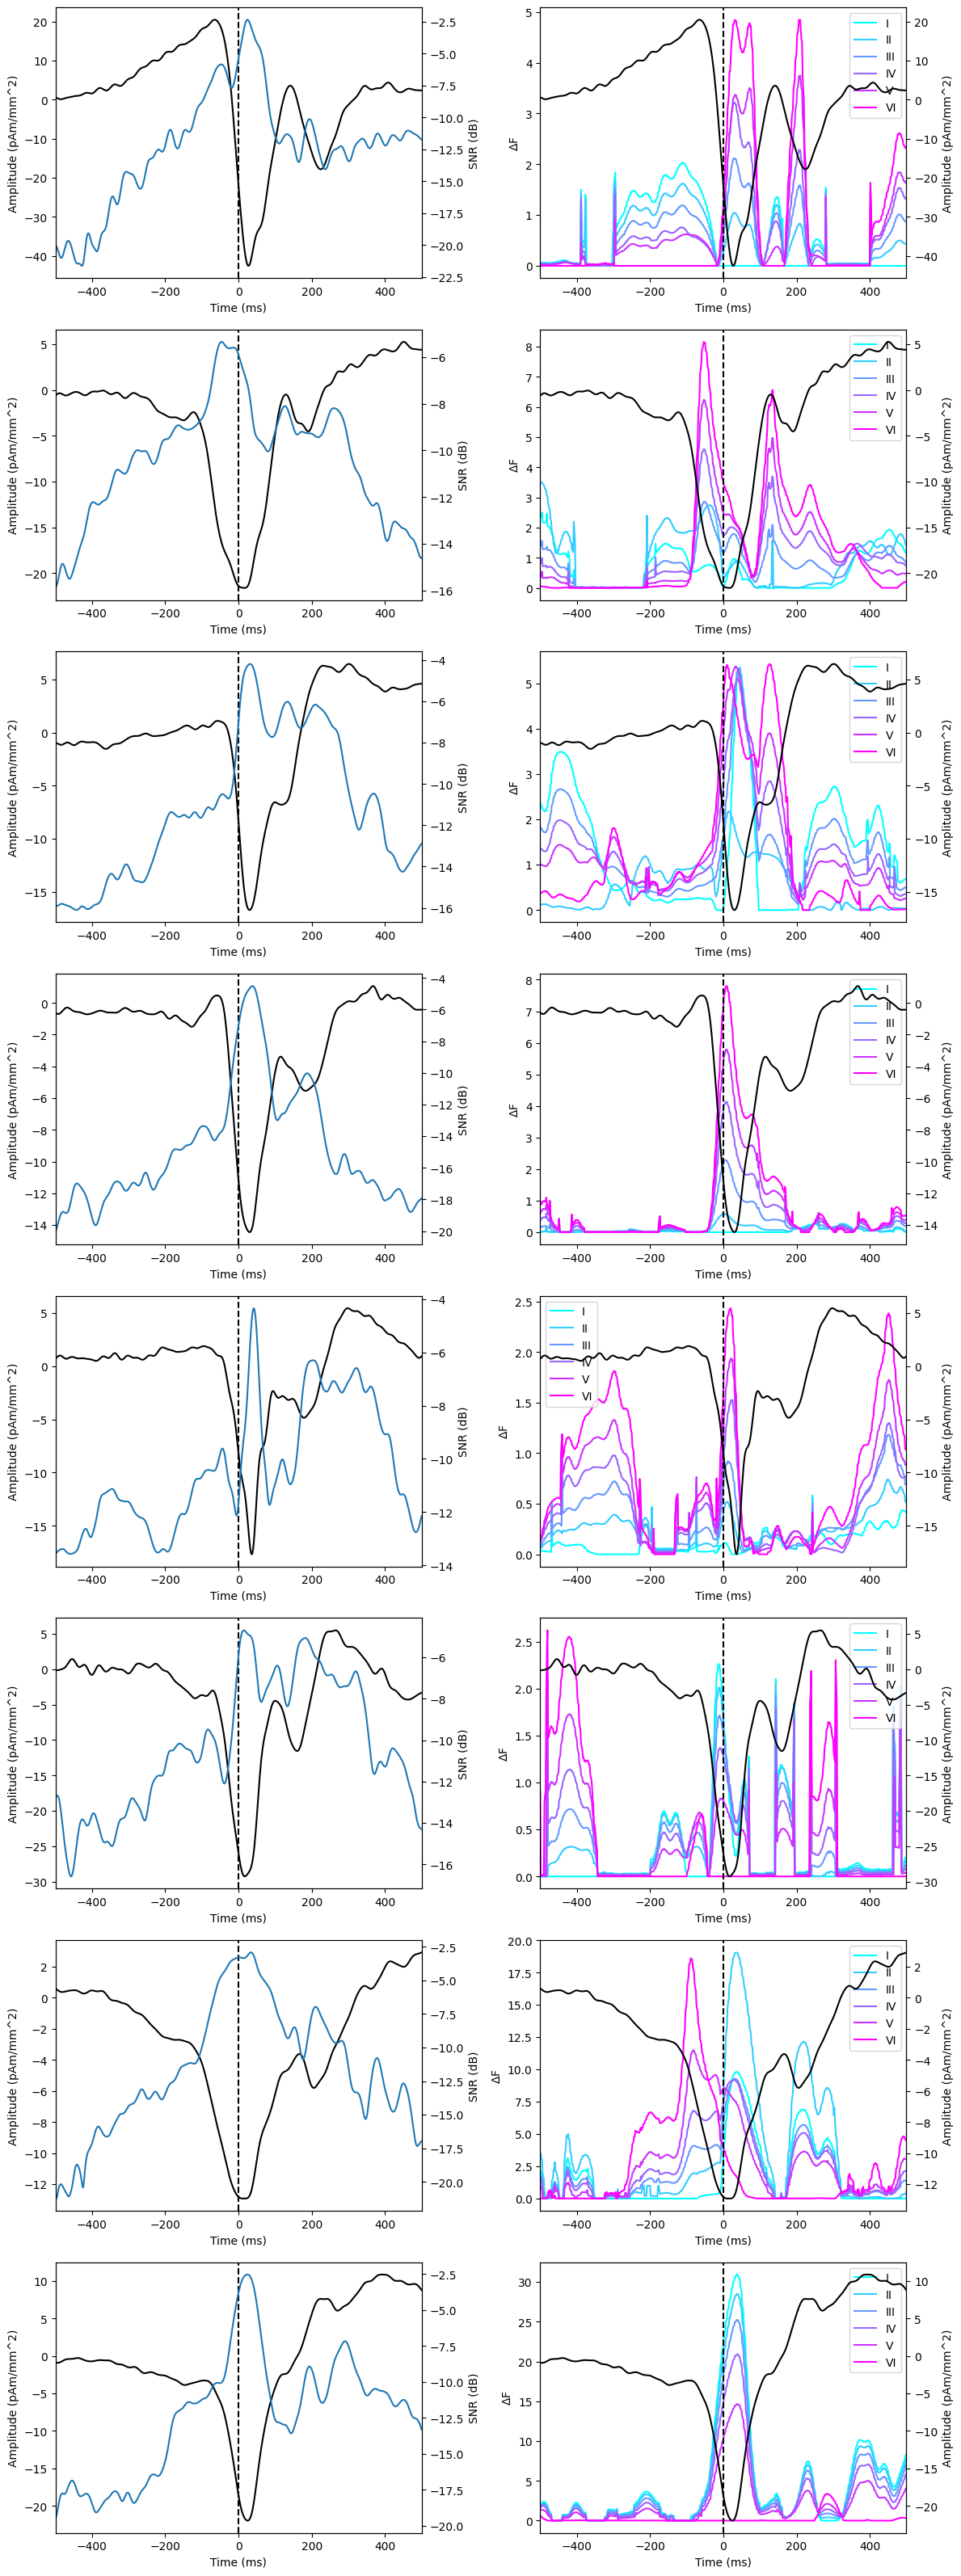

In [5]:
subjects_m_snrs = []
subjects_m_prior_ts = []
subjects_m_layer_F_diff = []

fig=plt.figure(figsize=(12,4*len(subjects)))

for s_idx, subject in enumerate(subjects):
    sess_idx = subj_session_idx[subject]
    subj_m_snrs = np.mean(all_snrs[sess_idx,:],axis=0)
    subj_m_prior_ts = np.mean(all_prior_ts[sess_idx,:],axis=0)
    subj_m_layer_F_diff = np.nanmean(all_layer_F_diff[sess_idx,:,:],axis=0)
    
    subjects_m_snrs.append(subj_m_snrs)
    subjects_m_prior_ts.append(subj_m_prior_ts)
    subjects_m_layer_F_diff.append(subj_m_layer_F_diff)
    
    ax=plt.subplot(len(subjects),2,s_idx*2+1)
    ax.plot(ts_time,subj_m_prior_ts,'k')
    ax.axvline(x=0, color='k', linestyle='--')
    ax2=ax.twinx()
    ax2.plot(sensor_time, subj_m_snrs)
    ax.set_ylabel('Amplitude (pAm/mm^2)')
    ax2.set_ylabel('SNR (dB)')
    ax.set_xlabel('Time (ms)')
    ax.set_xlim(time_lims)

    ax=plt.subplot(len(subjects),2,s_idx*2+2)
    col_l = plt.cm.cool(np.linspace(0,1, num=6))
    l_labels=['I','II','III','IV','V','VI']
    for i in range(6):
        ax.plot(woi_win, subj_m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
    ax.axvline(x=0, color='k', linestyle='--')
    plt.legend()
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel(r'$\Delta$F')
    ax2=ax.twinx()
    ax2.plot(ts_time,subj_m_prior_ts,'k')
    ax2.set_ylabel('Amplitude (pAm/mm^2)')
    ax.set_xlim(time_lims)

plt.tight_layout()
    
plt.savefig('./figure_SX_cued_action_mefI_subjects.pdf')

subjects_m_snrs = np.array(subjects_m_snrs)
subjects_m_prior_ts = np.array(subjects_m_prior_ts)
subjects_m_layer_F_diff = np.array(subjects_m_layer_F_diff)

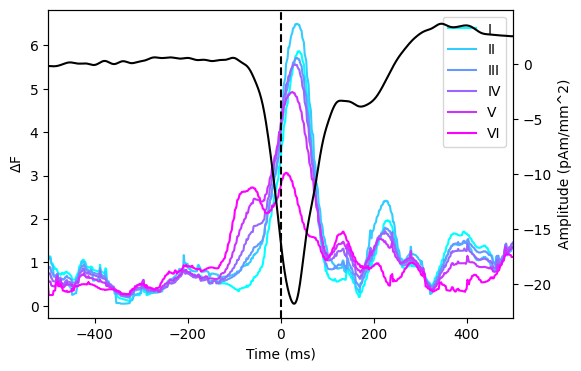

In [22]:
m_prior_ts=np.mean(subjects_m_prior_ts,axis=0)
m_layer_F_diff=np.nanmean(subjects_m_layer_F_diff,axis=0)

fig=plt.figure(figsize=(6,4))

ax=plt.subplot(1,1,1)
col_l = plt.cm.cool(np.linspace(0,1, num=6))
l_labels=['I','II','III','IV','V','VI']
for i in range(6):
    ax.plot(woi_win, m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
ax.axvline(x=0, color='k', linestyle='--')
plt.legend()
ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'$\Delta$F')
ax2=ax.twinx()
ax2.plot(ts_time,m_prior_ts,'k')
ax2.set_ylabel('Amplitude (pAm/mm^2)')
ax.set_xlim(time_lims)

plt.savefig('./figure_SX_cued_action_mefI.pdf')

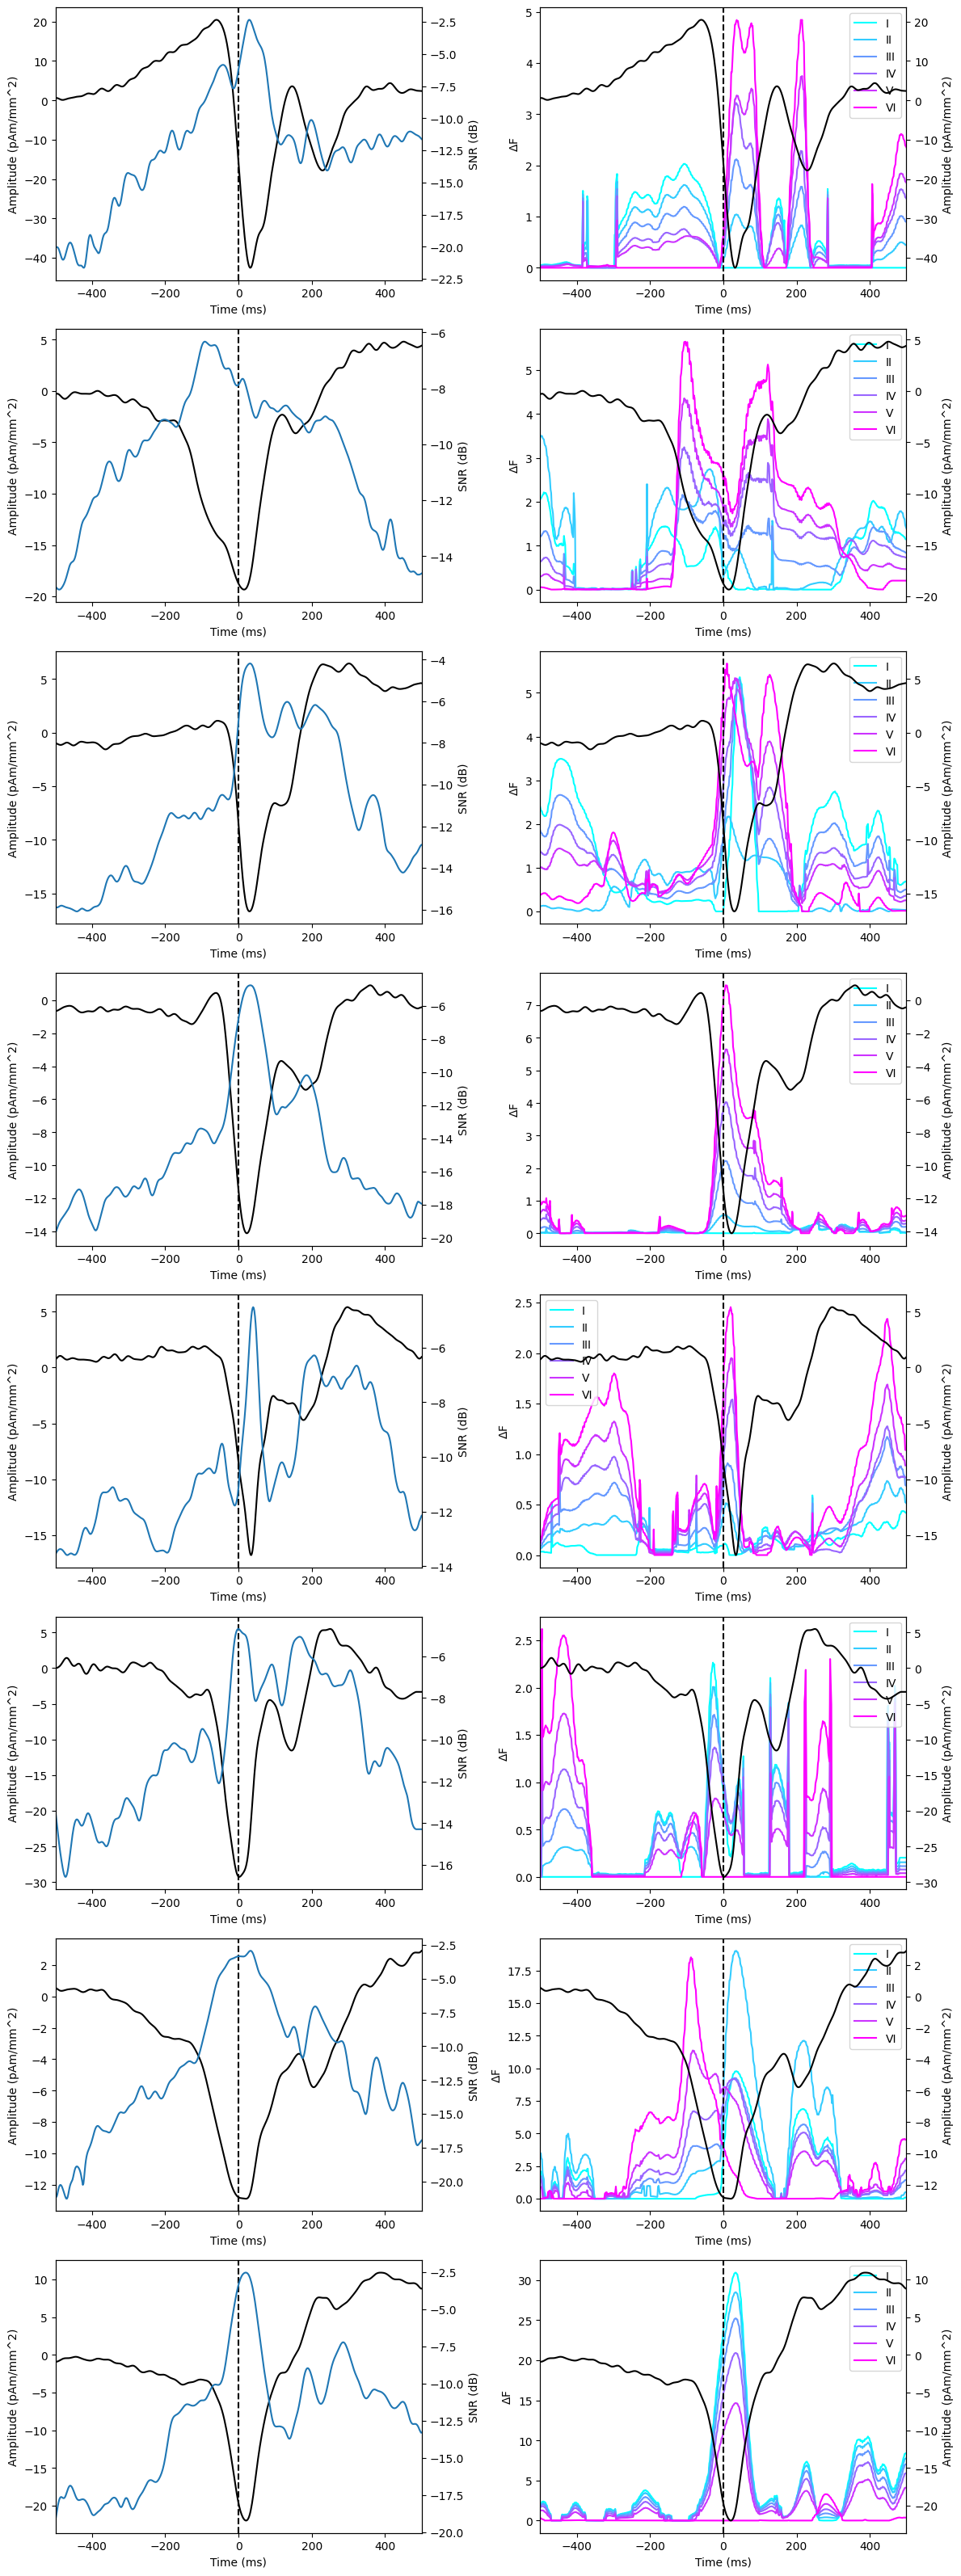

In [7]:
aligned_subjects_m_snrs = []
aligned_subjects_m_prior_ts = []
aligned_subjects_m_layer_F_diff = []

fig=plt.figure(figsize=(12,4*len(subjects)))

for s_idx, subject in enumerate(subjects):
    sess_idx = subj_session_idx[subject]
    subj_m_snrs = np.mean(aligned_snrs[sess_idx,:],axis=0)
    subj_m_prior_ts = np.mean(aligned_prior_ts[sess_idx,:],axis=0)
    subj_m_layer_F_diff = np.nanmean(aligned_layer_F_diff[sess_idx,:,:],axis=0)
    
    aligned_subjects_m_snrs.append(subj_m_snrs)
    aligned_subjects_m_prior_ts.append(subj_m_prior_ts)
    aligned_subjects_m_layer_F_diff.append(subj_m_layer_F_diff)

    ax=plt.subplot(len(subjects),2,s_idx*2+1)
    ax.plot(ts_time,subj_m_prior_ts,'k')
    ax.axvline(x=0, color='k', linestyle='--')
    ax2=ax.twinx()
    ax2.plot(sensor_time, subj_m_snrs)
    ax.set_ylabel('Amplitude (pAm/mm^2)')
    ax2.set_ylabel('SNR (dB)')
    ax.set_xlabel('Time (ms)')
    ax.set_xlim(time_lims)

    ax=plt.subplot(len(subjects),2,s_idx*2+2)
    col_l = plt.cm.cool(np.linspace(0,1, num=6))
    l_labels=['I','II','III','IV','V','VI']
    for i in range(6):
        ax.plot(woi_win, subj_m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
    ax.axvline(x=0, color='k', linestyle='--')
    plt.legend()
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel(r'$\Delta$F')
    ax2=ax.twinx()
    ax2.plot(ts_time,subj_m_prior_ts,'k')
    ax2.set_ylabel('Amplitude (pAm/mm^2)')
    ax.set_xlim(time_lims)

plt.tight_layout()
    
plt.savefig('./figure_SX_cued_action_mefI_subjects_aligned.pdf')

aligned_subjects_m_snrs = np.array(aligned_subjects_m_snrs)
aligned_subjects_m_prior_ts = np.array(aligned_subjects_m_prior_ts)
aligned_subjects_m_layer_F_diff = np.array(aligned_subjects_m_layer_F_diff)


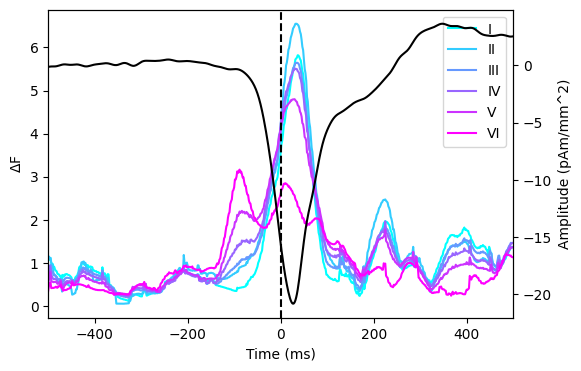

In [21]:
m_prior_ts=np.mean(aligned_subjects_m_prior_ts,axis=0)
m_layer_F_diff=np.nanmean(aligned_subjects_m_layer_F_diff,axis=0)

fig=plt.figure(figsize=(6,4))

ax=plt.subplot(1,1,1)
col_l = plt.cm.cool(np.linspace(0,1, num=6))
l_labels=['I','II','III','IV','V','VI']
for i in range(6):
    ax.plot(woi_win, m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
ax.axvline(x=0, color='k', linestyle='--')
plt.legend()
ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'$\Delta$F')
ax2=ax.twinx()
ax2.plot(ts_time,m_prior_ts,'k')
ax2.set_ylabel('Amplitude (pAm/mm^2)')
ax.set_xlim(time_lims)


plt.savefig('./figure_08_cued_action_mefI_aligned.pdf')